# Módulo 10 atividade 1

Uma instituição financeira quer conhecer melhor o perfil de renda de seus novos clientes para diversos fins, por exemplo, melhor dimensionar o limite de cartões de crédito dos novos clientes, sem necessariamente solicitar olerites ou documentações que impactem na experiência do seu cliente.

Para isto, conduziu um estudo com alguns clientes, comprovando suas rendas através de olerites e outros documentos, e pretende construir um modelo preditivo para esta renda com base em algumas variáveis que já possui em seu banco de dados.

As variáveis são intuitivas - note que há uma variável 'index' que é um identificador do cliente e que em geral o ```read_csv``` do pandas coloca também uma variável sequencial.

Estes dados estão no arquivo ```previsao_de_renda.csv```. Carregue-o em um *dataframe*.

1) Avalie a estrutura de correlação das variáveis quantitativas através de um gráfico de "matriz de dispersão" e através da avaliação gráfica da matriz de correlações. Veja se você identifica algum padrão interessante ou que te faça sentido.

In [2]:
#Carregar os dados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#carregar o dataset
df = pd.read_csv('previsao_de_renda.csv')

df.head()

,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


In [4]:
#Selecionar variaveis numéricas

df_num = df.select_dtypes(include=['int64','float64']).drop(columns=['index'], errors='ignore')

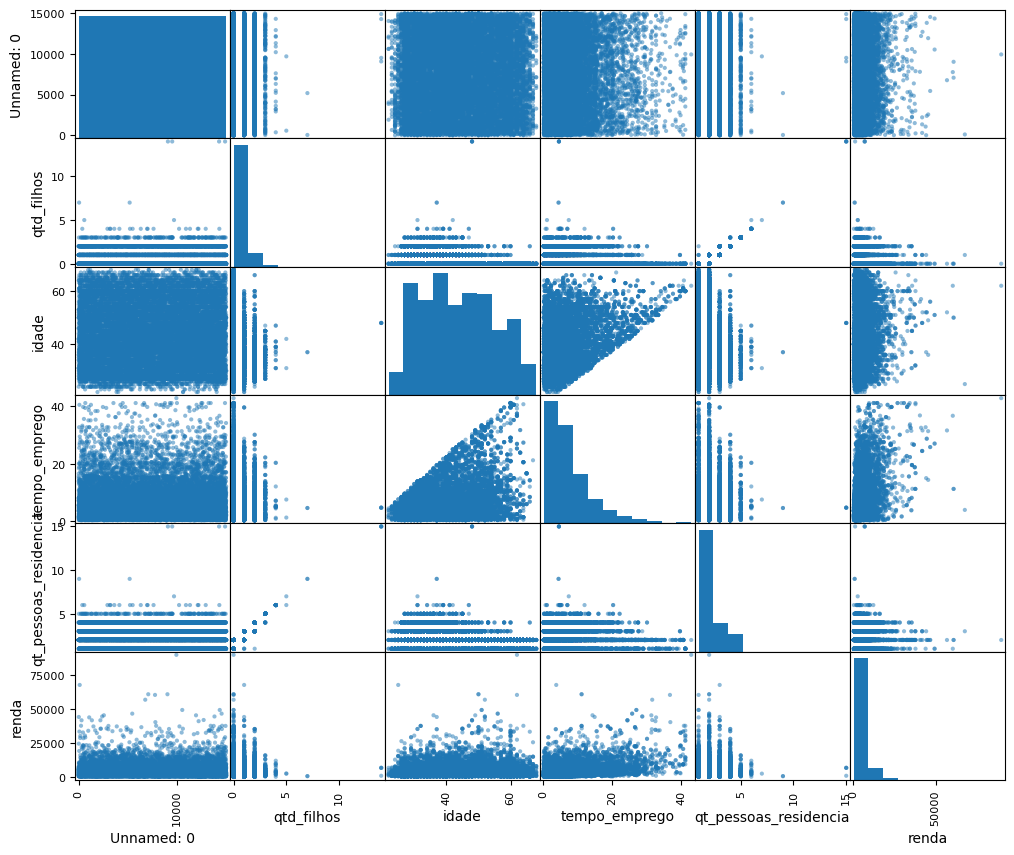

In [6]:
#Matriz de dispersão (scatter matrix)
pd.plotting.scatter_matrix(df_num,figsize=(12,10))
plt.show()

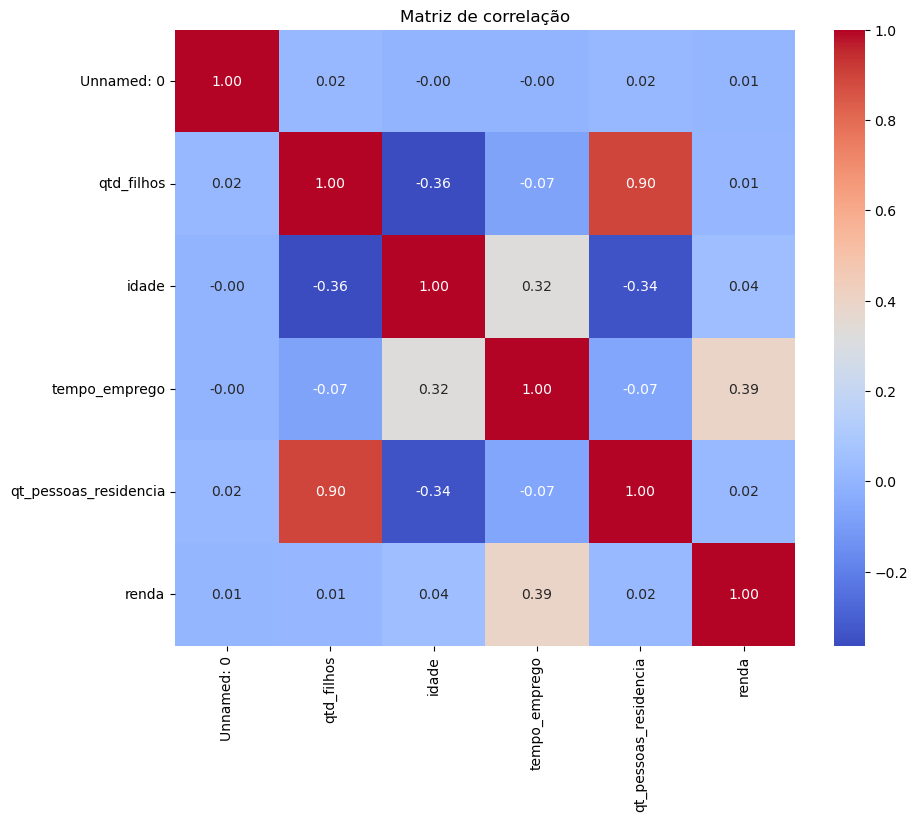

In [8]:
#Matriz de correlação (heatmap)
plt.figure(figsize=(10,8))
sns.heatmap(df_num.corr(),annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Matriz de correlação')
plt.show()

In [10]:
#Identificar variáveis mais correlacionadas com renda
corr = df_num.corr()

corr_renda = corr['renda'].sort_values(ascending=False)
print(corr_renda)

renda                    1.000000
tempo_emprego            0.394235
idade                    0.042570
qt_pessoas_residencia    0.020977
qtd_filhos               0.009567
Unnamed: 0               0.007646
Name: renda, dtype: float64


2) Avalie um gráfico de dispersão (*scatterplot*) específico para as duas variáveis mais correlacionadas com *renda*.

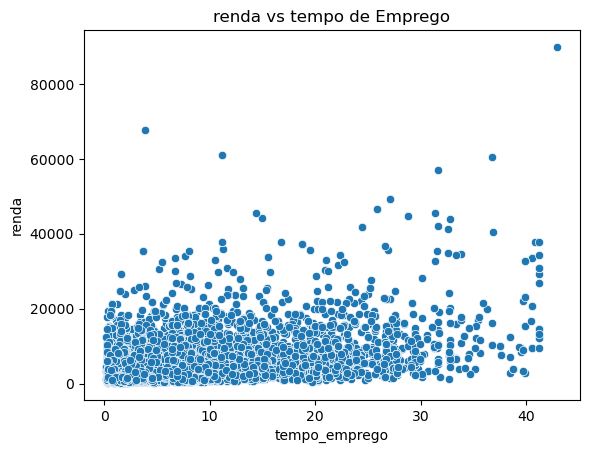

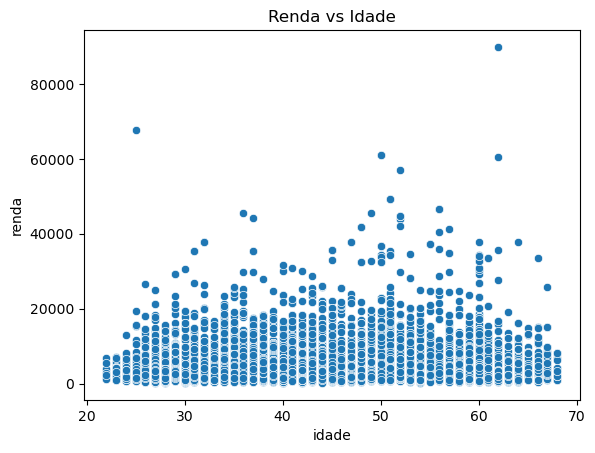

In [14]:
# tempo_emprego vs renda
sns.scatterplot(x='tempo_emprego', y='renda', data=df)
plt.title('renda vs tempo de Emprego')
plt.show()

#idade vs renda
sns.scatterplot(x='idade', y='renda', data=df)
plt.title('Renda vs Idade')
plt.show()

3) Na su aopinião, há outliers na variável renda?

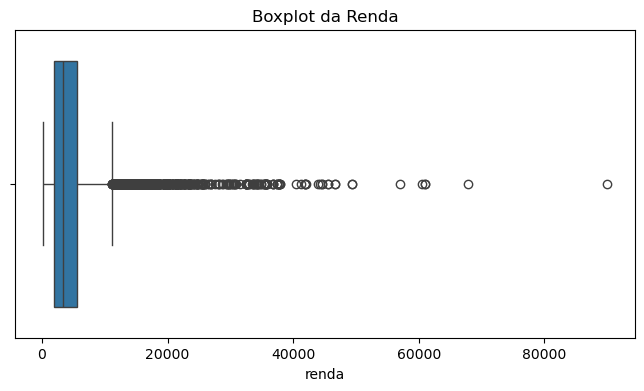

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['renda'])
plt.title('Boxplot da Renda')
plt.show()

4) Calcule o logaritmo da variável renda e repita a sequência de análise

In [18]:
#aplicando log na renda
df['log_renda'] = np.log(df['renda'])

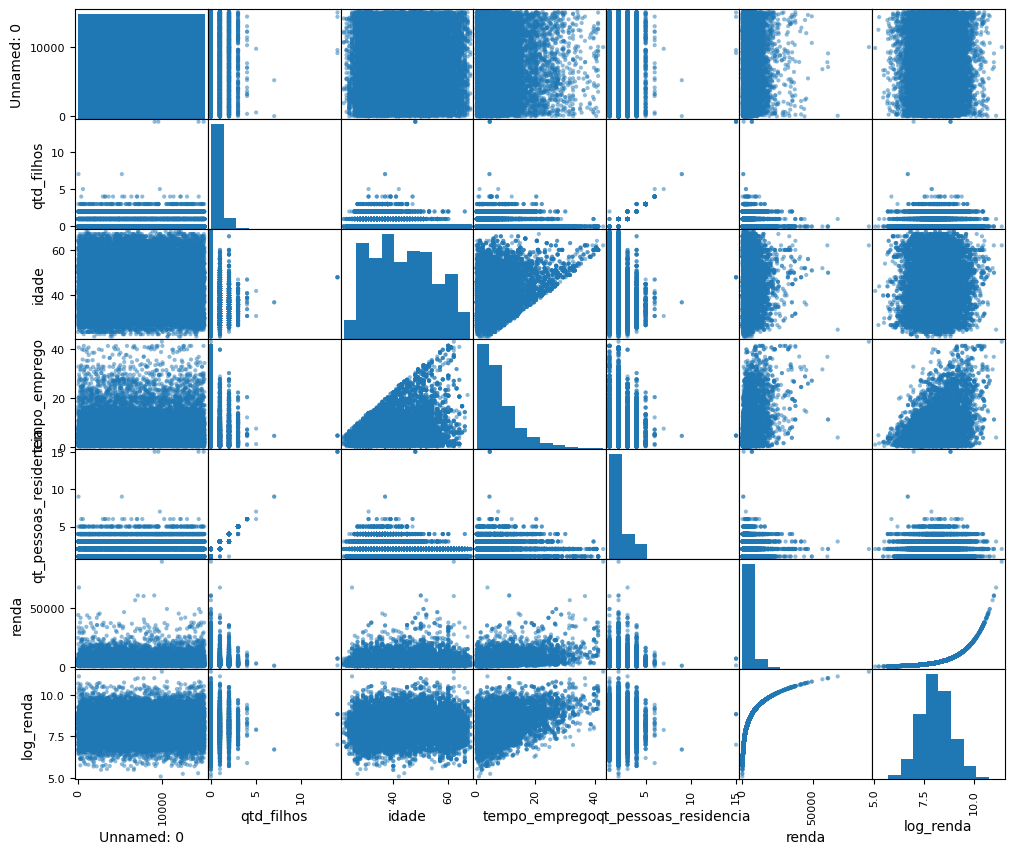

In [20]:
#Scatter matrix
df_log = df_num.copy()
df_log['log_renda'] = df['log_renda']

pd.plotting.scatter_matrix(df_log, figsize=(12,10))
plt.show()

In [21]:
#Correlação com log
corr_log = df_log.corr()

corr_log['log_renda'].sort_values(ascending=False)

log_renda                1.000000
renda                    0.835734
tempo_emprego            0.379556
qt_pessoas_residencia    0.036267
idade                    0.024712
qtd_filhos               0.023743
Unnamed: 0               0.004999
Name: log_renda, dtype: float64

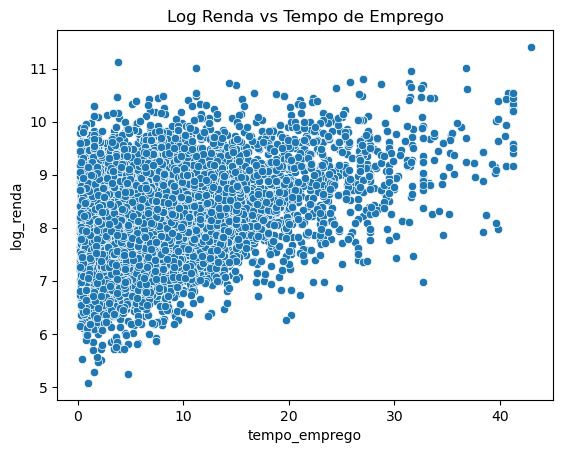

In [22]:
#Scatter com log
sns.scatterplot(x='tempo_emprego', y='log_renda', data=df)
plt.title('Log Renda vs Tempo de Emprego')
plt.show()

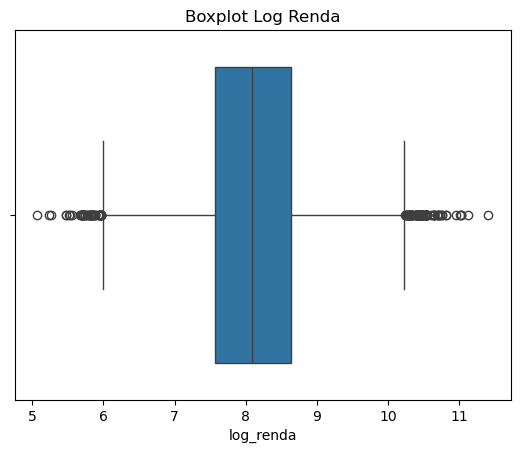

In [23]:
#Boxplot do log
sns.boxplot(x=df['log_renda'])
plt.title('Boxplot Log Renda')
plt.show()

5) A aplicação do LOG você acha que melhorou ou piorou a análise?

Sim, melhorou a análise, pois:

Reduziu a assimetria

Facilitou visualizar relações

Melhorou comportamento para modelagem